In [10]:
# 딥러닝 ..........

import torch
from torch import nn

dropout = nn.Dropout(0.2)
# 20% 확률로 랜덤하게 일부 요소를 0으로 만들겠다.

dummy = torch.arange(1, 11).float()

dropout(dummy)


tensor([ 1.2500,  2.5000,  3.7500,  5.0000,  6.2500,  7.5000,  8.7500, 10.0000,
        11.2500, 12.5000])




원본:   [ 1,  2,  3,  4,  5,  6,  7,  8,  9,  10]

마스크: [ 1,  0,  1,  1,  0,  1,  1,  1,  0,   1]  ← 20%만 0

결과:   [1.25, 0, 3.75, 5.0, 0, 7.5, 8.75, 10.0, 0, 12.5]  ← 살아남은 값 × 1.25


스케일 배수 = 1/(1-p)  -> 1/(1-0.2) = 1.25


Dropout -> 과적합(overfitting)방지
훈련 데이터에만 너무 맞춰져서 새로운 데이터에는 성능이 떨어지는 현상

Dropout 없이 학습:
뉴런들끼리 서로 '짜고 치는' 관계 형성
-> 훈련 데이터 암기

Dropout 적용:
매 배치마다 랜덤하게 뉴런을 제거
-> 어떤 뉴런이 없어질 지 모름 




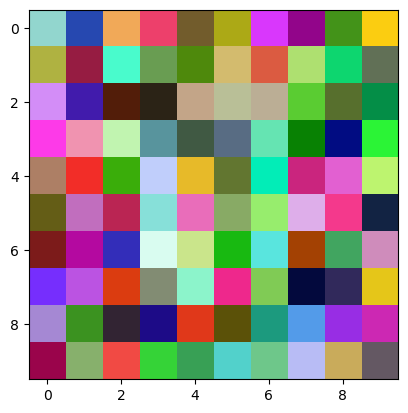

c:\Users\KDT51\miniconda3\envs\dev\Lib\site-packages\torch\nn\modules\dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


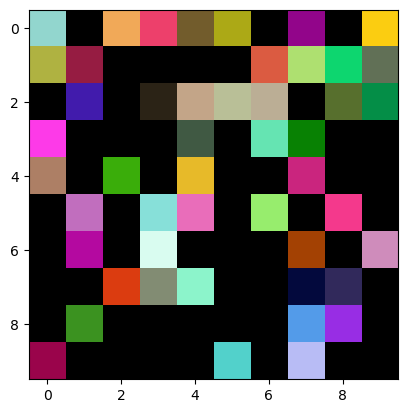

In [23]:
import matplotlib.pyplot as plt

a = torch.rand((3, 10, 10)) # C H W
plt.imshow(a.permute(1, 2, 0)) # H W C
plt.show()

# plt 는 H W C 형식이라서  C H W -> H W C 로 바꿔줘야함
# -> permute              0 1 2    1 2 0
 
dropout = nn.Dropout2d(0.5)


b = dropout(a.permute(1, 2, 0))
plt.imshow(b/2)